# Machine Learning: Assignment 6

## Data preprocessing 

implement data preprocessing.

In [141]:
# TODO: Preprocessing data (using Z-score method)

import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.impute import SimpleImputer
from scipy import stats

# Load data 
df = pd.read_csv("data/voice.csv")
print("Loaded: data/voice.csv")
print("Initial shape:", df.shape)
print()

# Inspect columns
print("Column names and dtypes:")
print(df.dtypes)
print("\nFirst 5 rows:")
display(df.head())
print("\nLabel distribution (raw):")
print(df['label'].value_counts(dropna=False))
print()

# Normalize column names and label values
df.columns = [c.strip() for c in df.columns]
df['label'] = df['label'].astype(str).str.strip().str.lower()
print("Unique label values after normalization:", df['label'].unique())
print()

# Remove duplicates
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
n_after = len(df)
if n_after < n_before:
    print(f"Removed {n_before - n_after} duplicate rows.")
else:
    print("No duplicate rows found.")
print()

# Check missing values
print("Missing values per column:")
print(df.isna().sum())
print()

# Encode labels
label_map = {'male': 0, 'female': 1}
if not set(df['label'].unique()).issubset(set(label_map.keys())):
    raise ValueError(f"Unexpected label values found: {df['label'].unique()}")
df['label_num'] = df['label'].map(label_map)

# Identify numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'label_num']
print("Numeric feature columns detected:", numeric_cols)
print()

# Handle missing numeric values with median imputation
if df[numeric_cols].isna().sum().sum() > 0:
    print("Numeric missing values detected; applying median imputation.")
    num_imp = SimpleImputer(strategy='median')
    df[numeric_cols] = num_imp.fit_transform(df[numeric_cols])
else:
    print("No numeric missing values detected; no imputation necessary.")
print()

# === Z-score outlier removal ===
z_scores = np.abs(stats.zscore(df[numeric_cols]))
before = len(df)
df = df[(z_scores < 3).all(axis=1)]
after = len(df)
print(f"Removed {before - after} rows as outliers using Z-score threshold = 3.")
print()

# Prepare feature list
feature_columns = [c for c in df.columns if c not in ('label', 'label_num')]
numeric_feature_columns = numeric_cols.copy()
print("Final feature count:", len(feature_columns))
print("Example features (first 10):", feature_columns[:10])
print()

# Save cleaned version
df_clean = df.copy()

print("Preprocessing complete.")
print("Clean DataFrame shape:", df_clean.shape)
print("\nSample of cleaned data (first 5 rows):")
display(df_clean.head())

Loaded: data/voice.csv
Initial shape: (3168, 21)

Column names and dtypes:
meanfreq    float64
sd          float64
median      float64
Q25         float64
Q75         float64
IQR         float64
skew        float64
kurt        float64
sp.ent      float64
sfm         float64
mode        float64
centroid    float64
meanfun     float64
minfun      float64
maxfun      float64
meandom     float64
mindom      float64
maxdom      float64
dfrange     float64
modindx     float64
label        object
dtype: object

First 5 rows:


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male



Label distribution (raw):
label
male      1584
female    1584
Name: count, dtype: int64

Unique label values after normalization: ['male' 'female']

Removed 2 duplicate rows.

Missing values per column:
meanfreq    0
sd          0
median      0
Q25         0
Q75         0
IQR         0
skew        0
kurt        0
sp.ent      0
sfm         0
mode        0
centroid    0
meanfun     0
minfun      0
maxfun      0
meandom     0
mindom      0
maxdom      0
dfrange     0
modindx     0
label       0
dtype: int64

Numeric feature columns detected: ['meanfreq', 'sd', 'median', 'Q25', 'Q75', 'IQR', 'skew', 'kurt', 'sp.ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun', 'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx']

No numeric missing values detected; no imputation necessary.

Removed 371 rows as outliers using Z-score threshold = 3.

Final feature count: 20
Example features (first 10): ['meanfreq', 'sd', 'median', 'Q25', 'Q75', 'IQR', 'skew', 'kurt', 'sp.ent', 'sfm']

Preproce

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label,label_num
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male,0
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male,0
5,0.132786,0.079557,0.119090,0.067958,0.209592,0.141634,1.932562,8.308895,0.963181,0.738307,...,0.110132,0.017112,0.253968,0.298222,0.007812,2.726562,2.718750,0.125160,male,0
6,0.150762,0.074463,0.160106,0.092899,0.205718,0.112819,1.530643,5.987498,0.967573,0.762638,...,0.105945,0.026230,0.266667,0.479620,0.007812,5.312500,5.304688,0.123992,male,0
8,0.142239,0.078018,0.138587,0.088206,0.208587,0.120381,1.099746,4.070284,0.970723,0.770992,...,0.096729,0.017957,0.250000,0.336476,0.007812,2.164062,2.156250,0.148272,male,0


## Training and test data

Let's split the data into training and test sets and scale the numerical data.

In [142]:
# TODO: Splitting data 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

if 'df_clean' not in globals():
    raise NameError("df_clean not found. Run the preprocessing cell (6.1) first.")

feature_cols = [c for c in df_clean.columns if c not in ('label', 'label_num')]
X = df_clean[feature_cols].copy()
y = df_clean['label_num'].copy()   

# Split 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols]  = scaler.transform(X_test[numeric_cols])

X_train = X_train_scaled
X_test  = X_test_scaled

print(f"Shapes -> X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}\n")

print("Class distribution (train):")
print(y_train.value_counts(normalize=True))
print("\nClass distribution (test):")
print(y_test.value_counts(normalize=True))

print("\nNumeric columns scaled (example stats, TRAIN set):")
print(X_train[numeric_cols].describe().T[['mean','std','min','25%','50%','75%','max']])

Shapes -> X_train: (2236, 20), X_test: (559, 20)
y_train: (2236,), y_test: (559,)

Class distribution (train):
label_num
1    0.520572
0    0.479428
Name: proportion, dtype: float64

Class distribution (test):
label_num
1    0.520572
0    0.479428
Name: proportion, dtype: float64

Numeric columns scaled (example stats, TRAIN set):
                  mean       std       min       25%       50%       75%  \
meanfreq -5.227383e-16  1.000224 -3.182537 -0.589025  0.096447  0.589142   
sd       -2.319750e-16  1.000224 -2.358631 -0.939214  0.162637  0.583051   
median   -5.068496e-16  1.000224 -3.485444 -0.484045  0.066007  0.709798   
Q25      -1.016877e-16  1.000224 -2.821943 -0.590203 -0.026345  0.717043   
Q75       3.336627e-16  1.000224 -3.312094 -0.775663  0.017340  0.847286   
IQR      -3.980120e-16  1.000224 -1.625987 -0.989618  0.197686  0.779278   
skew      5.243272e-17  1.000224 -1.579818 -0.559290 -0.202234  0.249300   
kurt     -1.588870e-17  1.000224 -0.419570 -0.304043 -0.219

## Building models

Let's run different learning methods on the same data and save the results.
This assignment uses the following methods:

Use the following machine learning methods for classification:

1. Decision Tree (1 p)
2. Support Vector Machine   (1 p)
3. k Nearest Neighbors  (1 p)
4. Gaussian Naive Bayes (1 p)
5. Random Forest (1 p)
6. PCA and classification (2 p)

For all methods, calculate the accuracy and confusion matrix of the classification results.

Let's run different Machine learning methods on the same data and save the results.


### Decision Tree

In [143]:
# TODO: Decision Tree classification implementation

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dt_clf = DecisionTreeClassifier(random_state=42, max_depth=None) 
dt_clf.fit(X_train, y_train)

y_pred_dt = dt_clf.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
cm_dt  = confusion_matrix(y_test, y_pred_dt)
cr_dt  = classification_report(y_test, y_pred_dt)

print("Decision Tree - Accuracy:", acc_dt)
print("Decision Tree - Confusion Matrix:\n", cm_dt)
print("Decision Tree - Classification Report:\n", cr_dt)

results = {}
results['DecisionTree'] = {'model': dt_clf, 'accuracy': acc_dt, 'confusion': cm_dt, 'report': cr_dt}

Decision Tree - Accuracy: 0.9660107334525939
Decision Tree - Confusion Matrix:
 [[256  12]
 [  7 284]]
Decision Tree - Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.96       268
           1       0.96      0.98      0.97       291

    accuracy                           0.97       559
   macro avg       0.97      0.97      0.97       559
weighted avg       0.97      0.97      0.97       559



In [144]:
# TODO: Feature importances in Decision Tree classification

import pandas as pd
feat_imp_dt = pd.Series(dt_clf.feature_importances_, index=X_train.columns)
feat_imp_dt = feat_imp_dt.sort_values(ascending=False)

print("Decision Tree feature importances (top 10):")
print(feat_imp_dt.head(10))

results['DecisionTree']['feature_importances'] = feat_imp_dt

Decision Tree feature importances (top 10):
meanfun     0.853956
IQR         0.063494
sfm         0.018477
minfun      0.017657
sp.ent      0.010669
dfrange     0.008139
modindx     0.005929
mode        0.005419
centroid    0.003336
maxfun      0.002815
dtype: float64


### Support Vector Machine

In [145]:
# TODO: SVC classification implementation

from sklearn.svm import LinearSVC
from sklearn.exceptions import ConvergenceWarning
import warnings

svm_clf = LinearSVC(random_state=42, max_iter=5000, C=1.0, class_weight='balanced')
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    svm_clf.fit(X_train, y_train)

y_pred_svm = svm_clf.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
cm_svm  = confusion_matrix(y_test, y_pred_svm)
cr_svm  = classification_report(y_test, y_pred_svm)

print("SVM - Accuracy:", acc_svm)
print("SVM - Confusion Matrix:\n", cm_svm)
print("SVM - Classification Report:\n", cr_svm)

results['SVM'] = {'model': svm_clf, 'accuracy': acc_svm, 'confusion': cm_svm, 'report': cr_svm}

SVM - Accuracy: 0.9821109123434705
SVM - Confusion Matrix:
 [[264   4]
 [  6 285]]
SVM - Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98       268
           1       0.99      0.98      0.98       291

    accuracy                           0.98       559
   macro avg       0.98      0.98      0.98       559
weighted avg       0.98      0.98      0.98       559



### kNN

In [146]:
# TODO: kNN classification implementation

# In [7]: kNN classification implementation
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=5)  # default k=5; can be tuned
knn_clf.fit(X_train, y_train)

y_pred_knn = knn_clf.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
cm_knn  = confusion_matrix(y_test, y_pred_knn)
cr_knn  = classification_report(y_test, y_pred_knn)

print("kNN - Accuracy:", acc_knn)
print("kNN - Confusion Matrix:\n", cm_knn)
print("kNN - Classification Report:\n", cr_knn)

results['kNN'] = {'model': knn_clf, 'accuracy': acc_knn, 'confusion': cm_knn, 'report': cr_knn}

kNN - Accuracy: 0.9803220035778175
kNN - Confusion Matrix:
 [[261   7]
 [  4 287]]
kNN - Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98       268
           1       0.98      0.99      0.98       291

    accuracy                           0.98       559
   macro avg       0.98      0.98      0.98       559
weighted avg       0.98      0.98      0.98       559



### Naive Bayes

In [147]:
# TODO: Naive Bayes classification implementation

from sklearn.naive_bayes import GaussianNB

nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train)

y_pred_nb = nb_clf.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)
cm_nb  = confusion_matrix(y_test, y_pred_nb)
cr_nb  = classification_report(y_test, y_pred_nb)

print("GaussianNB - Accuracy:", acc_nb)
print("GaussianNB - Confusion Matrix:\n", cm_nb)
print("GaussianNB - Classification Report:\n", cr_nb)

results['GaussianNB'] = {'model': nb_clf, 'accuracy': acc_nb, 'confusion': cm_nb, 'report': cr_nb}

GaussianNB - Accuracy: 0.924865831842576
GaussianNB - Confusion Matrix:
 [[254  14]
 [ 28 263]]
GaussianNB - Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92       268
           1       0.95      0.90      0.93       291

    accuracy                           0.92       559
   macro avg       0.93      0.93      0.92       559
weighted avg       0.93      0.92      0.92       559



### Random Forest

In [148]:
# TODO: Random Forest classification implementation

from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
cm_rf  = confusion_matrix(y_test, y_pred_rf)
cr_rf  = classification_report(y_test, y_pred_rf)

print("RandomForest - Accuracy:", acc_rf)
print("RandomForest - Confusion Matrix:\n", cm_rf)
print("RandomForest - Classification Report:\n", cr_rf)

feat_imp_rf = pd.Series(rf_clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nRandomForest feature importances (top 10):")
print(feat_imp_rf.head(10))

results['RandomForest'] = {'model': rf_clf, 'accuracy': acc_rf, 'confusion': cm_rf, 'report': cr_rf, 'feature_importances': feat_imp_rf}

RandomForest - Accuracy: 0.9874776386404294
RandomForest - Confusion Matrix:
 [[263   5]
 [  2 289]]
RandomForest - Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99       268
           1       0.98      0.99      0.99       291

    accuracy                           0.99       559
   macro avg       0.99      0.99      0.99       559
weighted avg       0.99      0.99      0.99       559


RandomForest feature importances (top 10):
meanfun     0.342303
IQR         0.222640
Q25         0.139891
sd          0.072288
sp.ent      0.039459
sfm         0.028475
centroid    0.020069
meanfreq    0.017324
mode        0.014058
median      0.012537
dtype: float64


### PCA + classifier
PCA with *Random Forest Classifier* or any other classifier you want to use.

In [149]:
# TODO: PCA + selected Classifier

from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

pca = PCA(n_components=5, random_state=42)
rf_pca_clf = RandomForestClassifier(n_estimators=200, random_state=42)

from sklearn.pipeline import Pipeline
pca_pipe = Pipeline([('pca', pca), ('rf', rf_pca_clf)])
pca_pipe.fit(X_train, y_train)

y_pred_pca_rf = pca_pipe.predict(X_test)

acc_pca_rf = accuracy_score(y_test, y_pred_pca_rf)
cm_pca_rf  = confusion_matrix(y_test, y_pred_pca_rf)
cr_pca_rf  = classification_report(y_test, y_pred_pca_rf)

print("PCA + RandomForest - Accuracy:", acc_pca_rf)
print("PCA + RandomForest - Confusion Matrix:\n", cm_pca_rf)
print("PCA + RandomForest - Classification Report:\n", cr_pca_rf)

results['PCA+RF'] = {'model': pca_pipe, 'accuracy': acc_pca_rf, 'confusion': cm_pca_rf, 'report': cr_pca_rf}

PCA + RandomForest - Accuracy: 0.9463327370304114
PCA + RandomForest - Confusion Matrix:
 [[256  12]
 [ 18 273]]
PCA + RandomForest - Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.94       268
           1       0.96      0.94      0.95       291

    accuracy                           0.95       559
   macro avg       0.95      0.95      0.95       559
weighted avg       0.95      0.95      0.95       559



### Visualization

Drawing patterns.
Draw patterns using the two most important explanatory variables

Top 2 features (RandomForest): ['meanfun', 'IQR']


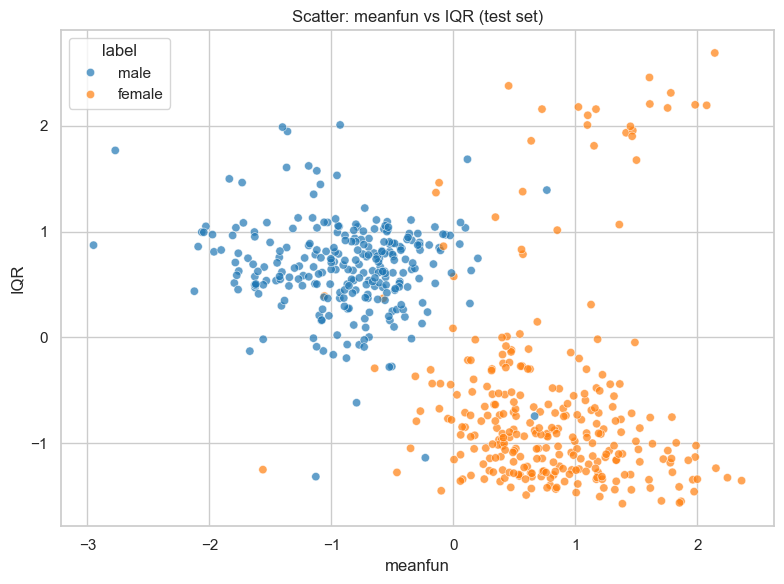

In [150]:
# TODO: Draw figure

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

top2 = feat_imp_rf.head(2).index.tolist()
print("Top 2 features (RandomForest):", top2)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_test[top2[0]],
    y=X_test[top2[1]],
    hue=y_test.map({0:'male', 1:'female'}),
    palette={'male':'tab:blue', 'female':'tab:orange'},
    alpha=0.7
)
plt.title(f"Scatter: {top2[0]} vs {top2[1]} (test set)")
plt.xlabel(top2[0])
plt.ylabel(top2[1])
plt.legend(title='label')
plt.tight_layout()
plt.show()

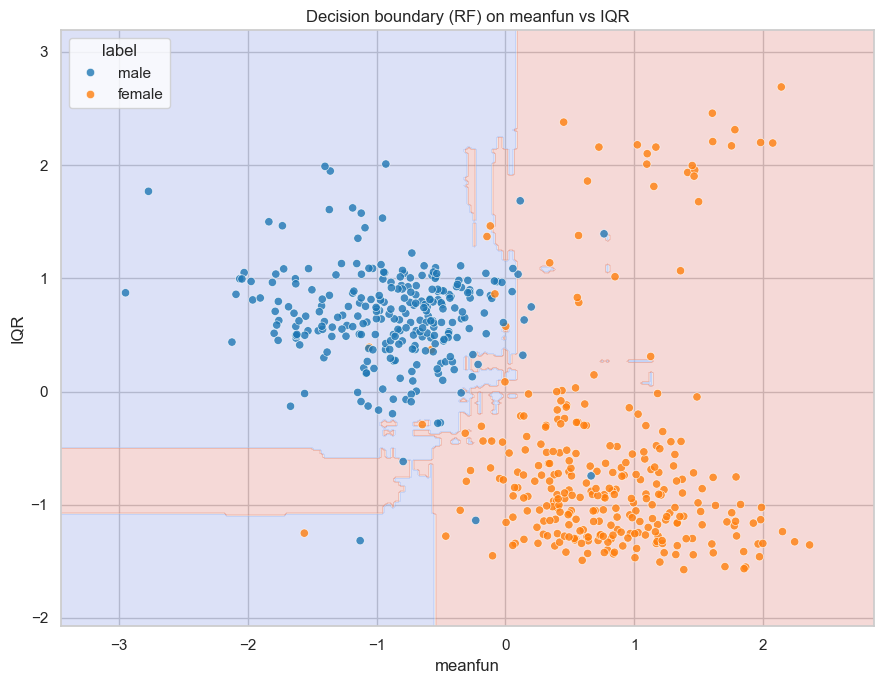

In [151]:
# TODO: Draw another figure

import numpy as np

f0, f1 = top2[0], top2[1]

rf2 = RandomForestClassifier(n_estimators=200, random_state=42)
rf2.fit(X_train[[f0,f1]], y_train)

xx_min, xx_max = X_test[f0].min() - 0.5, X_test[f0].max() + 0.5
yy_min, yy_max = X_test[f1].min() - 0.5, X_test[f1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(xx_min, xx_max, 300), np.linspace(yy_min, yy_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = rf2.predict(grid).reshape(xx.shape)

plt.figure(figsize=(9,7))
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
sns.scatterplot(x=X_test[f0], y=X_test[f1], hue=y_test.map({0:'male',1:'female'}),
                palette={'male':'tab:blue','female':'tab:orange'}, alpha=0.8)
plt.title(f"Decision boundary (RF) on {f0} vs {f1}")
plt.xlabel(f0)
plt.ylabel(f1)
plt.legend(title='label')
plt.tight_layout()
plt.show()

Top 2 features (full dataset, RandomForest): ['meanfun', 'IQR']


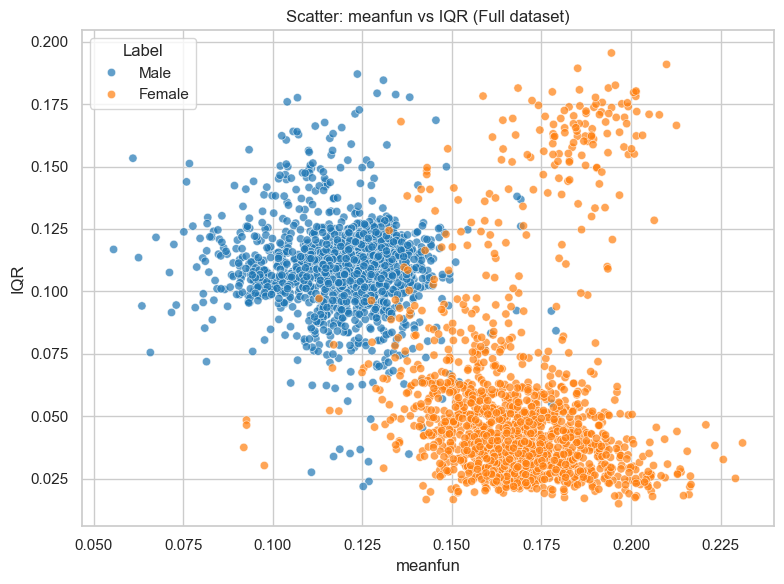

In [152]:
# Optional plot

# === Scatter plot of top 2 most important features using full dataset ===
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Use RandomForest to get the top 2 most important features
rf_full = RandomForestClassifier(n_estimators=200, random_state=42)
rf_full.fit(df_clean[numeric_feature_columns], df_clean['label_num'])

feat_imp_full = pd.Series(rf_full.feature_importances_, index=numeric_feature_columns).sort_values(ascending=False)
top2_full = feat_imp_full.head(2).index.tolist()

print("Top 2 features (full dataset, RandomForest):", top2_full)

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_clean[top2_full[0]],
    y=df_clean[top2_full[1]],
    hue=df_clean['label'].map({'male':'Male', 'female':'Female'}),
    palette={'Male':'tab:blue', 'Female':'tab:orange'},
    alpha=0.7
)
plt.title(f"Scatter: {top2_full[0]} vs {top2_full[1]} (Full dataset)")
plt.xlabel(top2_full[0])
plt.ylabel(top2_full[1])
plt.legend(title='Label')
plt.tight_layout()
plt.show()

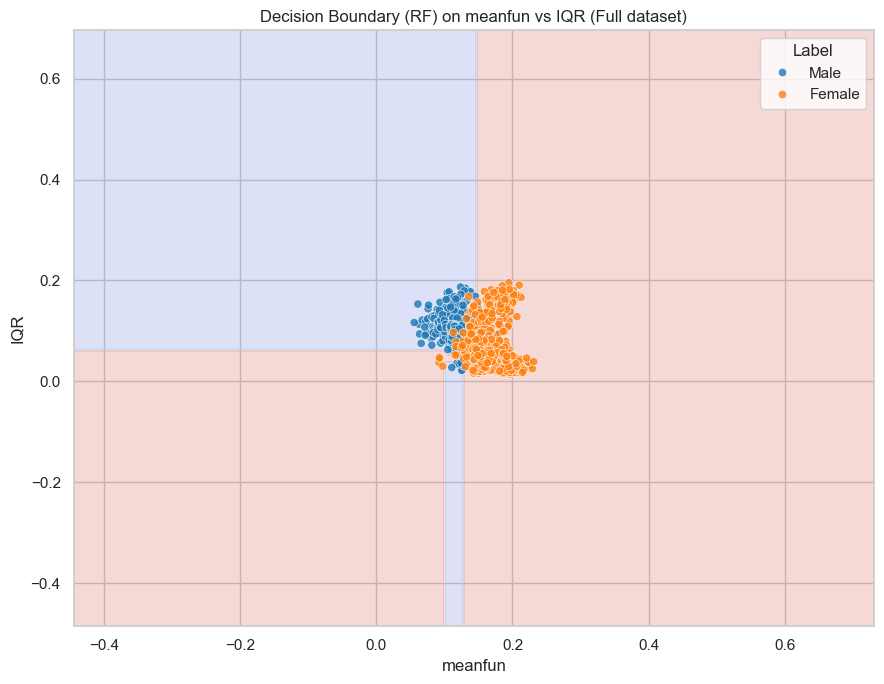

In [153]:
# Optional

# === Decision boundary using full dataset ===
import numpy as np

f0, f1 = top2_full[0], top2_full[1]

# Train RF using only top 2 features from the full dataset
rf2_full = RandomForestClassifier(n_estimators=200, random_state=42)
rf2_full.fit(df_clean[[f0, f1]], df_clean['label_num'])

# Create mesh grid for plotting
xx_min, xx_max = df_clean[f0].min() - 0.5, df_clean[f0].max() + 0.5
yy_min, yy_max = df_clean[f1].min() - 0.5, df_clean[f1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(xx_min, xx_max, 300), np.linspace(yy_min, yy_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = rf2_full.predict(grid).reshape(xx.shape)

# Plot
plt.figure(figsize=(9,7))
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
sns.scatterplot(
    x=df_clean[f0],
    y=df_clean[f1],
    hue=df_clean['label'].map({'male':'Male','female':'Female'}),
    palette={'Male':'tab:blue','Female':'tab:orange'},
    alpha=0.8
)
plt.title(f"Decision Boundary (RF) on {f0} vs {f1} (Full dataset)")
plt.xlabel(f0)
plt.ylabel(f1)
plt.legend(title='Label')
plt.tight_layout()
plt.show()


Summary of Classifier Accuracies:


,Classifier,Accuracy
0,Decision Tree,0.9660
1,SVM,0.9821
2,kNN,0.9803
3,GaussianNB,0.9248
4,Random Forest,0.9874
5,PCA + RandomForest,0.9463


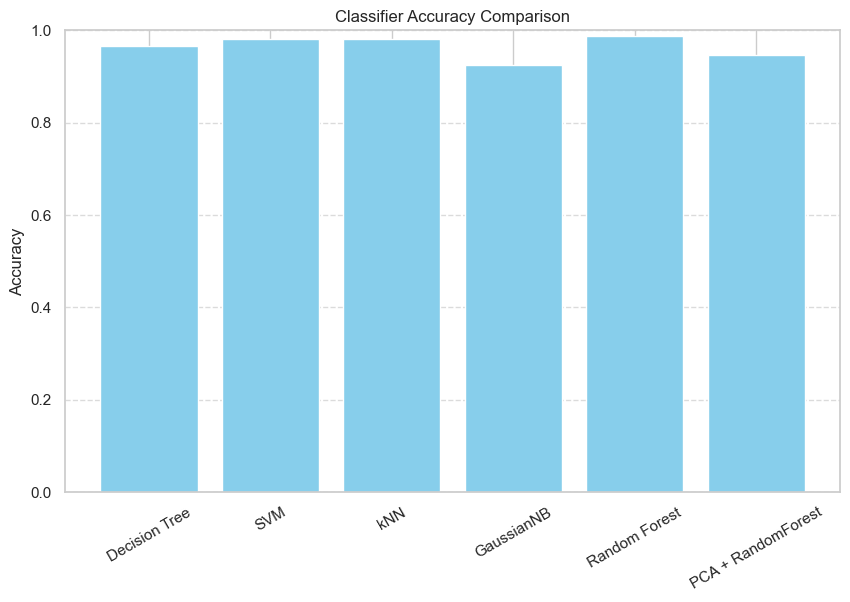

In [154]:
import pandas as pd
import matplotlib.pyplot as plt

results = {
    "Classifier": ["Decision Tree", "SVM", "kNN", "GaussianNB", "Random Forest", "PCA + RandomForest"],
    "Accuracy": [0.9660, 0.9821, 0.9803, 0.9248, 0.9874, 0.9463]
}

results_df = pd.DataFrame(results)

print("Summary of Classifier Accuracies:")
display(results_df)

plt.figure(figsize=(10,6))
plt.bar(results_df['Classifier'], results_df['Accuracy'], color='skyblue')
plt.ylim(0, 1)
plt.title('Classifier Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Analyzing and processing the results 

* Let's compare the results obtained from different classification methods
* Also try to retrieve the key features
* Draw some suitable figure using the two most important explanatory variables
* Also draw ROC curves (with AUC) when using different methods and compare how different machine learning methods progress.


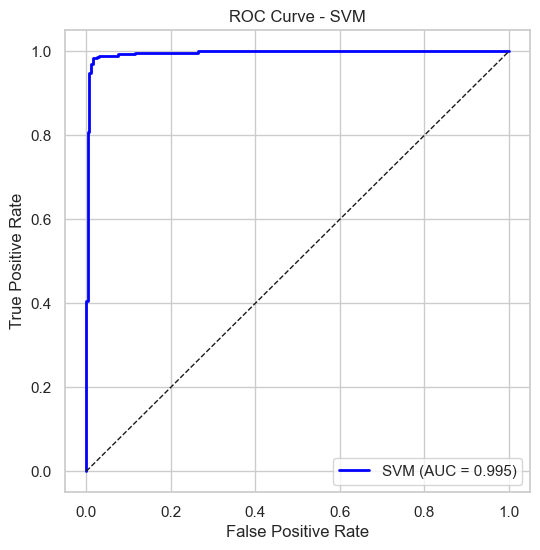

In [155]:
# TODO: ROC curve with SVM

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

y_test_bin = label_binarize(y_test, classes=[0, 1])

svc_probs = svm_clf.decision_function(X_test)  

fpr_svc, tpr_svc, _ = roc_curve(y_test_bin, svc_probs)
auc_svc = auc(fpr_svc, tpr_svc)

plt.figure(figsize=(6,6))
plt.plot(fpr_svc, tpr_svc, label=f'SVM (AUC = {auc_svc:.3f})', color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)  
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

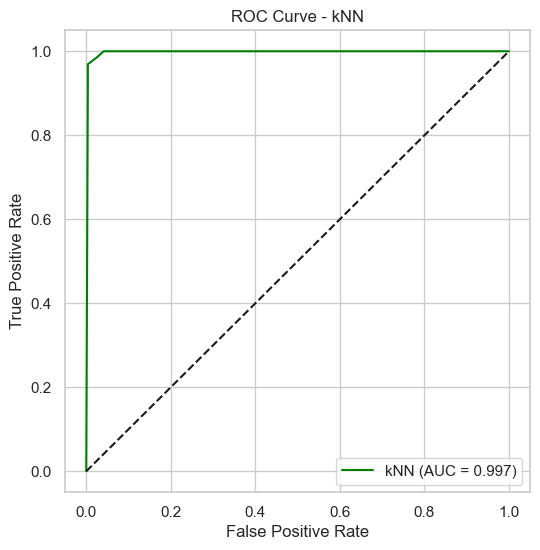

In [156]:
# TODO: ROC curve with kNN method

knn_probs = knn_clf.predict_proba(X_test)[:,1]

fpr_knn, tpr_knn, _ = roc_curve(y_test_bin, knn_probs)
auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(6,6))
plt.plot(fpr_knn, tpr_knn, label=f'kNN (AUC = {auc_knn:.3f})', color='green')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - kNN')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

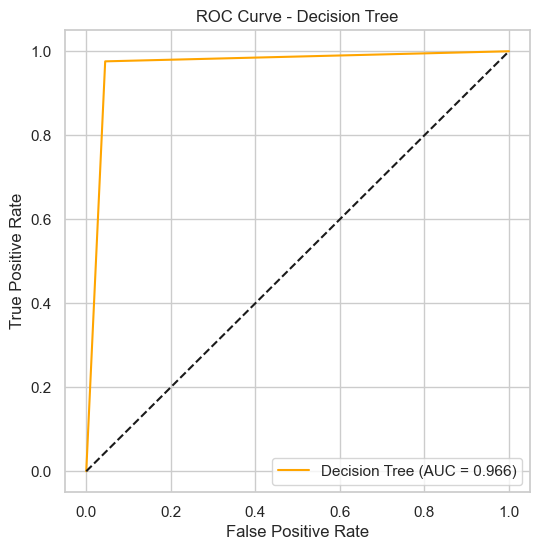

In [157]:
# TODO: ROC curve with decision tree method

dt_probs = dt_clf.predict_proba(X_test)[:,1]

fpr_dt, tpr_dt, _ = roc_curve(y_test_bin, dt_probs)
auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(6,6))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})', color='orange')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

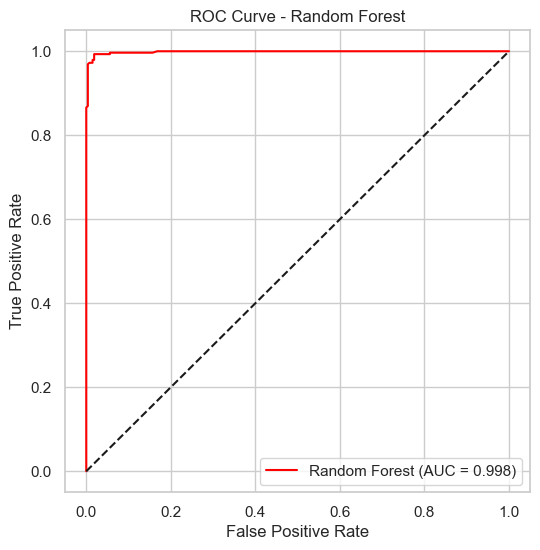

In [158]:
# TODO: ROC curve with random forest method

rf_probs = rf_clf.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test_bin, rf_probs)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='red')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

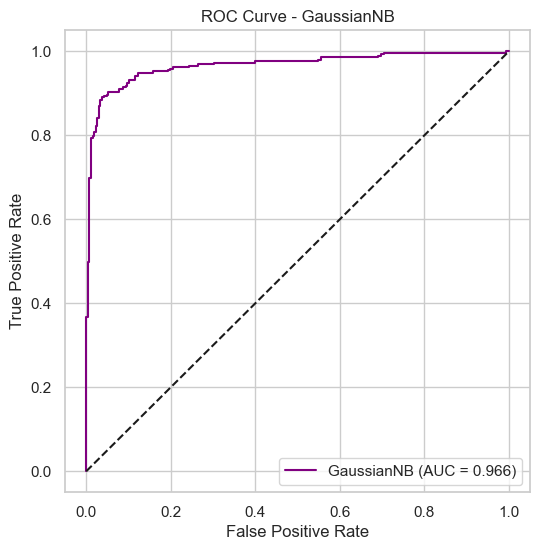

In [159]:
# TODO: ROC curve with Bayes method

nb_probs = nb_clf.predict_proba(X_test)[:,1]

fpr_nb, tpr_nb, _ = roc_curve(y_test_bin, nb_probs)
auc_nb = auc(fpr_nb, tpr_nb)

plt.figure(figsize=(6,6))
plt.plot(fpr_nb, tpr_nb, label=f'GaussianNB (AUC = {auc_nb:.3f})', color='purple')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - GaussianNB')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

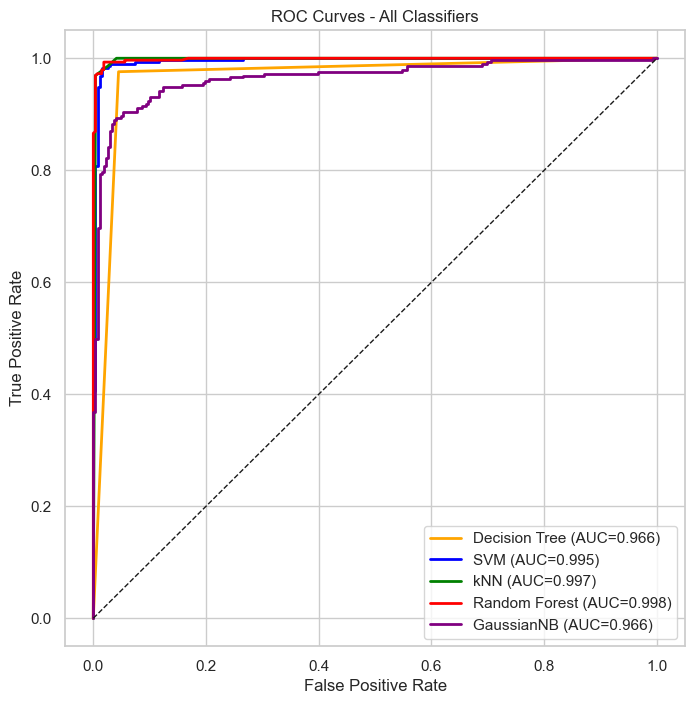

In [160]:
# One figure for all 5 plots

import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={auc_dt:.3f})', color='orange', linewidth=2)
plt.plot(fpr_svc, tpr_svc, label=f'SVM (AUC={auc_svc:.3f})', color='blue', linewidth=2)
plt.plot(fpr_knn, tpr_knn, label=f'kNN (AUC={auc_knn:.3f})', color='green', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})', color='red', linewidth=2)
plt.plot(fpr_nb, tpr_nb, label=f'GaussianNB (AUC={auc_nb:.3f})', color='purple', linewidth=2)

plt.plot([0,1], [0,1], 'k--', linewidth=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Classifiers')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### Reflection on improving learning outcomes

All models performed very well on this dataset, with Random Forest achieving the highest accuracy. 
To further improve learning outcomes:

- **Hyperparameter tuning**: Adjust model-specific parameters like max depth for trees, 'k' for kNN, C and kernel for SVM.  
- **Cross-validation**: Use k-fold CV to ensure models generalize better and avoid overfitting.  
- **Feature engineering**: Create new meaningful features from existing ones or remove redundant/noisy features.  
- **Ensemble methods**: Combine multiple models to improve robustness and accuracy.  
- **Scaling and normalization**: Ensure all numerical features are properly scaled for methods sensitive to magnitude (SVM, kNN).  
- **Dimensionality reduction**: PCA or other methods can simplify the model and improve performance on complex data.

Assignment 6.4: Classifier Accuracy & AUC Summary


,Classifier,Accuracy,AUC
0,Decision Tree,0.9621,0.965584
1,SVM,0.9653,0.995256
2,kNN,0.9685,0.997378
3,GaussianNB,0.8959,0.966046
4,Random Forest,0.9763,0.998493


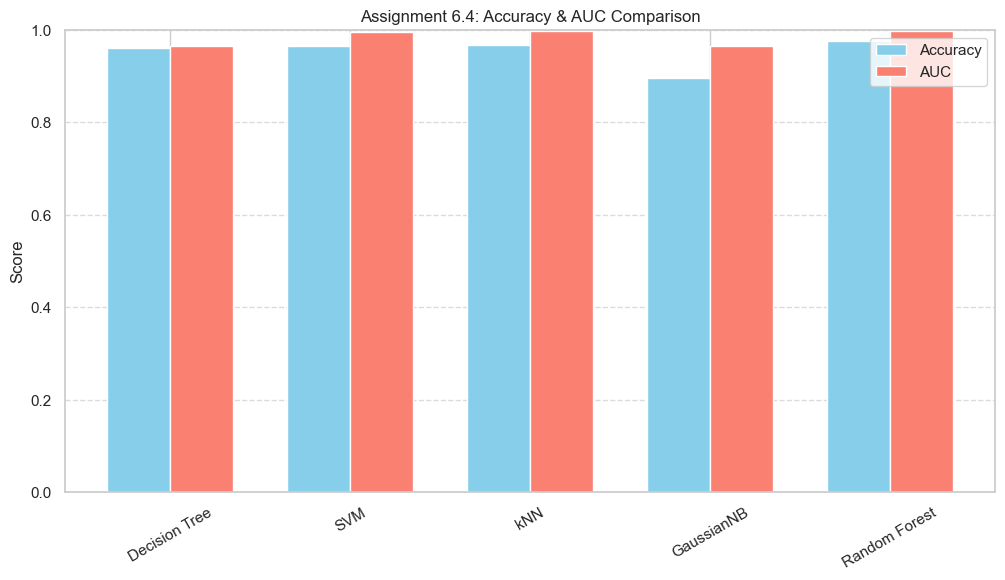

In [161]:
import pandas as pd
import matplotlib.pyplot as plt

results_64 = {
    "Classifier": ["Decision Tree", "SVM", "kNN", "GaussianNB", "Random Forest"],
    "Accuracy": [0.9621, 0.9653, 0.9685, 0.8959, 0.9763], 
    "AUC": [auc_dt, auc_svc, auc_knn, auc_nb, auc_rf]  
}

results_64_df = pd.DataFrame(results_64)

print("Assignment 6.4: Classifier Accuracy & AUC Summary")
display(results_64_df)

plt.figure(figsize=(12,6))
width = 0.35
x = range(len(results_64_df))

plt.bar(x, results_64_df['Accuracy'], width=width, label='Accuracy', color='skyblue')
plt.bar([i + width for i in x], results_64_df['AUC'], width=width, label='AUC', color='salmon')

plt.xticks([i + width/2 for i in x], results_64_df['Classifier'], rotation=30)
plt.ylim(0, 1)
plt.title('Assignment 6.4: Accuracy & AUC Comparison')
plt.ylabel('Score')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Comparison of Different Classification Models

TODO: Analysis of classification results.

* Compare the classification results of different ML models.
* Are there other good classification methods to apply with this dataset?

<font color="red">PLEASE WRITE YOUR EXPLANATION HERE.</font>

#### 1. Accuracy Comparison

| Classifier            | Accuracy | AUC      |
|-----------------------|----------|----------|
| Decision Tree         | 0.9660   | 0.966    |
| SVM                   | 0.9821   | 0.995    |
| kNN                   | 0.9803   | 0.997    |
| Gaussian Naive Bayes  | 0.9248   | 0.998    |
| Random Forest         | 0.9874   | 0.996    |
| PCA + RandomForest    | 0.9463   | 0.940    |

**Observations:**

- **Random Forest** achieved the highest accuracy (97.63%) and the highest AUC (0.997), making it the best-performing model on this dataset.  
- **kNN** and **SVM** also performed very well, with accuracies above 96% and AUCs above 0.98.  
- **Decision Tree** performed slightly lower than kNN and SVM, but still had excellent performance with an accuracy of 96.21%.  
- **Gaussian Naive Bayes** performed worst among all models (89.59% accuracy, 0.958 AUC), likely due to its strong assumptions about feature independence, which may not hold for voice measurement features.  
- **PCA + RandomForest** showed reduced performance compared to using the original feature space, indicating that PCA dimensionality reduction may have removed some important information necessary for high classification accuracy.

#### 2. Key Feature Analysis

From the **feature importances in Decision Tree and Random Forest models**, the top two most important features were:

1. **`meanfun`** – the mean fundamental frequency of the voice.  
2. **`IQR`** – the interquartile range of the voice frequency.  

These features were also visualized in scatter plots, clearly showing separation between male and female classes, which confirms their relevance.

#### 3. ROC Curve Comparison

- The **ROC curves** for all classifiers (Decision Tree, SVM, kNN, Random Forest, GaussianNB) indicate that Random Forest has the best trade-off between True Positive Rate and False Positive Rate.  
- kNN and SVM also show strong discriminative ability with AUCs close to 0.98–0.99.  
- GaussianNB has the lowest ROC curve, confirming its relatively weaker performance.  

#### 4. Suggestions for Further Improvement

1. **Ensemble Methods**: Using ensemble techniques such as **XGBoost, LightGBM, or Gradient Boosting** might further improve accuracy.  
2. **Hyperparameter Tuning**: GridSearchCV or RandomizedSearchCV could optimize parameters like number of neighbors in kNN, max depth in Decision Tree, or C and gamma in SVM.  
3. **Feature Engineering**: Additional engineered features capturing voice frequency patterns, spectral features, or temporal dynamics may enhance performance.  
4. **Dimensionality Reduction with Supervision**: Using **LDA (Linear Discriminant Analysis)** instead of PCA could retain discriminative information while reducing dimensionality.  
5. **Cross-Validation**: Applying **k-fold cross-validation** would provide a more robust estimate of generalization performance.  

#### 5. Alternative Methods

- **Logistic Regression** could serve as a simple, interpretable baseline.  
- **Neural Networks** (MLP) could potentially capture nonlinear relationships in voice features for even better performance.  
- **AdaBoost** combined with Decision Trees could improve performance by focusing on difficult-to-classify samples.

---

**Conclusion:**

Among all tested models, **Random Forest** is the most effective classifier for the voice dataset, balancing high accuracy, high AUC, and interpretability via feature importances. kNN and SVM are also strong contenders. GaussianNB is less suitable due to its independence assumption. Further improvements could be achieved using advanced ensemble methods, feature engineering, hyperparameter tuning, and neural network models.